# MVTec AD — Experiment Results
**BAP: XAI-Supported Evaluation of Model Degradation in Visual Inspection**  
Marwan Elkhallouki · HOGENT AI & Data Engineering

Loads every `output/<category>_<corruption>_results.npz` file and visualises:
1. AUROC degradation curves per corruption type
2. AUROC heat-map (category × severity)
3. Summary statistics table

---
## 0 · Setup

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import sys
ROOT = Path.cwd().resolve()
WORK_PYTHON_CANDIDATES = [
    ROOT,
    ROOT / "work" / "python",
    ROOT.parent / "work" / "python",
    ROOT.parent.parent / "work" / "python",
]
WORK_PYTHON = next((p for p in WORK_PYTHON_CANDIDATES if (p / "config.py").exists()), None)
if WORK_PYTHON is None:
    raise RuntimeError("Could not locate work/python (config.py). Open notebook from repo root or work/python.")
if str(WORK_PYTHON) not in sys.path:
    sys.path.insert(0, str(WORK_PYTHON))

from config import MVTEC_CATEGORIES, CORRUPTION_TYPES

OUTPUT_CANDIDATES = [
    ROOT / 'output',
    ROOT.parent / 'output',
    ROOT.parent.parent / 'output',
]
OUTPUT_DIR = next((p for p in OUTPUT_CANDIDATES if p.exists()), OUTPUT_CANDIDATES[0])
print(f"Using OUTPUT_DIR: {OUTPUT_DIR}")

# If multiple scenarios are present, default to single_progressive for apples-to-apples charts.
SCENARIO_FILTER = 'single_progressive'  # set to None to include all scenarios

def parse_result_filename(stem: str):
    if not stem.endswith('_results'):
        return None
    base = stem[:-8]
    for cat in sorted(MVTEC_CATEGORIES, key=len, reverse=True):
        prefix = f"{cat}_"
        if base.startswith(prefix):
            corr = base[len(prefix):]
            if corr in CORRUPTION_TYPES:
                return cat, corr
    return None

file_rows = []
for f in sorted(OUTPUT_DIR.glob('*_results.npz')):
    d = np.load(f, allow_pickle=True)

    cat_meta = d['category'].item() if 'category' in d.files else None
    corr_meta = d['corruption'].item() if 'corruption' in d.files else None
    scen_meta = d['stream_scenario'].item() if 'stream_scenario' in d.files else 'legacy'

    if isinstance(cat_meta, str) and isinstance(corr_meta, str):
        category, corruption = cat_meta, corr_meta
    else:
        parsed = parse_result_filename(f.stem)
        if parsed is None:
            continue
        category, corruption = parsed

    file_rows.append({
        'file': f.name,
        'path': str(f),
        'mtime': f.stat().st_mtime,
        'category': category,
        'corruption': corruption,
        'scenario': scen_meta,
        'auroc_severities': d['auroc_severities'].astype(int),
        'auroc_values': d['auroc_values'].astype(float),
    })

if not file_rows:
    raise RuntimeError(f"No parseable *_results.npz files found in {OUTPUT_DIR}. Run run_experiment.py first.")

files_df = pd.DataFrame(file_rows)

# Keep latest file per (category, corruption, scenario) to avoid multi-run overplotting.
files_df = files_df.sort_values('mtime').drop_duplicates(['category', 'corruption', 'scenario'], keep='last')

if SCENARIO_FILTER is not None:
    files_df = files_df[files_df['scenario'] == SCENARIO_FILTER].copy()

records = []
for _, r in files_df.iterrows():
    for sev, auc in zip(r['auroc_severities'], r['auroc_values']):
        records.append(dict(category=r['category'], corruption=r['corruption'],
                            severity=int(sev), auroc=float(auc),
                            file=r['file'], scenario=r['scenario']))

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError(f"No rows after scenario filtering (SCENARIO_FILTER={SCENARIO_FILTER!r}).")

bad_cat = sorted(set(df['category']) - set(MVTEC_CATEGORIES))
if bad_cat:
    raise RuntimeError(f"Unexpected categories in parsed results: {bad_cat}.")

dups = df.groupby(['category', 'corruption', 'severity']).size().reset_index(name='n')
if (dups['n'] > 1).any():
    raise RuntimeError('Duplicate points remain after de-duplication; refusing to plot ambiguous curves.')

# Coverage sanity to catch category-specific overplot artifacts early.
coverage = df.groupby(['category', 'corruption']).size().unstack(fill_value=0)
print('Coverage rows per (category, corruption):')
print(coverage.to_string())

CATEGORIES  = sorted(df['category'].unique())
CORRUPTIONS = sorted(df['corruption'].unique())
SEVERITIES  = sorted(df['severity'].unique())

print(f'Loaded {len(df)} data points from {df["file"].nunique()} files')
print(f'  Scenario filter: {SCENARIO_FILTER}')
print(f'  Categories  : {CATEGORIES}')
print(f'  Corruptions : {CORRUPTIONS}')
print(f'  Severities  : {SEVERITIES}')
print()
print(df.to_string(index=False))


Using OUTPUT_DIR: /home/marwan/School/3de/BAP/BAP/work/python/output
Coverage rows per (category, corruption):
corruption  brightness  defocus_blur  gaussian_noise  held_out_defects  jpeg_compression  rotation  translation
category                                                                                                       
bottle               6             6               6                 1                 6         2            2
carpet               6             6               6                 1                 6         2            2
leather              6             6               6                 1                 6         2            2
metal_nut            6             6               6                 1                 6         2            2
transistor           6             6               6                 1                 6         2            2
Loaded 145 data points from 35 files
  Scenario filter: single_progressive
  Categories  : ['bottle', 'ca

---
## 1 · AUROC Degradation Curves

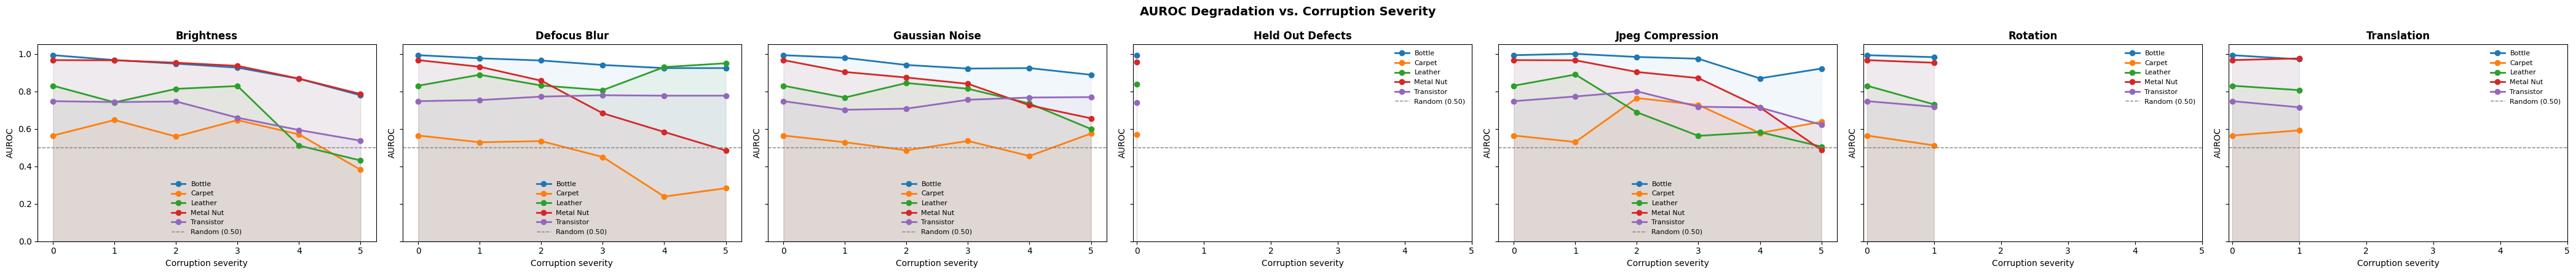

In [35]:
# One subplot per corruption type; one line per category
CAT_COLORS = plt.cm.tab10.colors

n_corr = len(CORRUPTIONS)
fig, axes = plt.subplots(1, n_corr, figsize=(6 * n_corr, 4.5), sharey=True)
if n_corr == 1:
    axes = [axes]

fig.suptitle('AUROC Degradation vs. Corruption Severity', fontsize=14, fontweight='bold')

for ax, corr in zip(axes, CORRUPTIONS):
    sub = df[df['corruption'] == corr]
    for idx, cat in enumerate(CATEGORIES):
        row = sub[sub['category'] == cat].sort_values('severity')
        if row.empty:
            continue
        ax.plot(row['severity'], row['auroc'],
                marker='o', linewidth=2,
                color=CAT_COLORS[idx % len(CAT_COLORS)],
                label=cat.replace('_', ' ').title())
        ax.fill_between(row['severity'], row['auroc'], alpha=0.06,
                        color=CAT_COLORS[idx % len(CAT_COLORS)])

    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Random (0.50)')
    ax.set_title(corr.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Corruption severity')
    ax.set_ylabel('AUROC')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(SEVERITIES)
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

---
## 2 · AUROC Heat-map (category × severity)

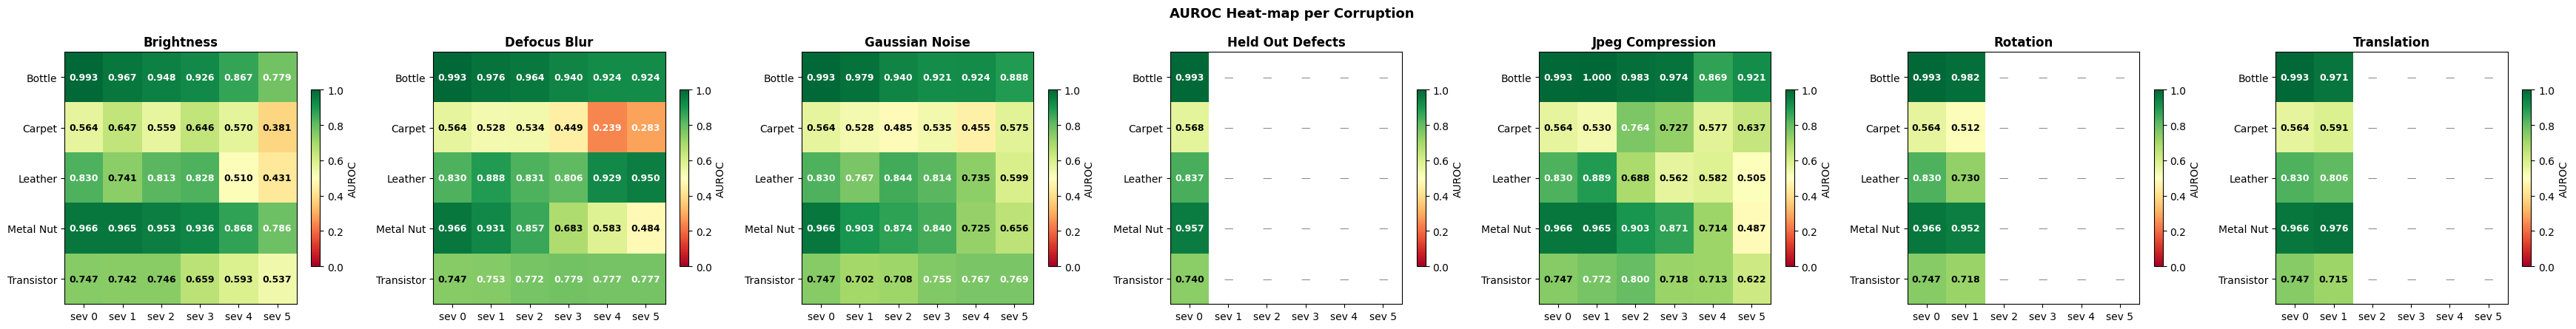

In [36]:
n_corr = len(CORRUPTIONS)
fig, axes = plt.subplots(1, n_corr, figsize=(5 * n_corr, max(2.5, 0.6 * len(CATEGORIES) + 1.5)))
if n_corr == 1:
    axes = [axes]

fig.suptitle('AUROC Heat-map per Corruption', fontsize=13, fontweight='bold')

cmap = 'RdYlGn'

for ax, corr in zip(axes, CORRUPTIONS):
    sub = df[df['corruption'] == corr]
    matrix = pd.DataFrame(index=CATEGORIES, columns=SEVERITIES, dtype=float)
    for _, row in sub.iterrows():
        matrix.loc[row['category'], row['severity']] = row['auroc']

    im = ax.imshow(matrix.values.astype(float), aspect='auto',
                   cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(SEVERITIES)))
    ax.set_xticklabels([f'sev {s}' for s in SEVERITIES])
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels([c.replace('_', ' ').title() for c in CATEGORIES])
    ax.set_title(corr.replace('_', ' ').title(), fontweight='bold')

    for i, cat in enumerate(CATEGORIES):
        for j, sev in enumerate(SEVERITIES):
            val = matrix.loc[cat, sev]
            if pd.notna(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='black' if 0.3 < val < 0.75 else 'white')
            else:
                ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='grey')

    plt.colorbar(im, ax=ax, shrink=0.7, label='AUROC')

plt.tight_layout()
plt.show()

---
## 3 · Summary Statistics Table

In [37]:
# Pivot: rows = category, cols = (corruption, severity)
pivot = df.pivot_table(index='category', columns=['corruption', 'severity'],
                       values='auroc', aggfunc='first')
pivot.columns = [f'{c} / sev{s}' for c, s in pivot.columns]
pivot.index = [c.replace('_', ' ').title() for c in pivot.index]

print('AUROC per category, corruption and severity:')
print(pivot.round(4).to_string())

# Per-category stats
print('\nPer-category summary (across all available results):')
stats = df.groupby('category')['auroc'].agg(['mean', 'min', 'max', 'std']).round(4)
stats.index = [c.replace('_', ' ').title() for c in stats.index]
print(stats.to_string())

AUROC per category, corruption and severity:
            brightness / sev0  brightness / sev1  brightness / sev2  brightness / sev3  brightness / sev4  brightness / sev5  defocus_blur / sev0  defocus_blur / sev1  defocus_blur / sev2  defocus_blur / sev3  defocus_blur / sev4  defocus_blur / sev5  gaussian_noise / sev0  gaussian_noise / sev1  gaussian_noise / sev2  gaussian_noise / sev3  gaussian_noise / sev4  gaussian_noise / sev5  held_out_defects / sev0  jpeg_compression / sev0  jpeg_compression / sev1  jpeg_compression / sev2  jpeg_compression / sev3  jpeg_compression / sev4  jpeg_compression / sev5  rotation / sev0  rotation / sev1  translation / sev0  translation / sev1
Bottle                 0.9929             0.9667             0.9476             0.9262             0.8667             0.7786               0.9929               0.9762               0.9643               0.9405               0.9238               0.9238                 0.9929                 0.9786                 0.94

---
## 4 · AUROC Drop per Category (severity min → max)

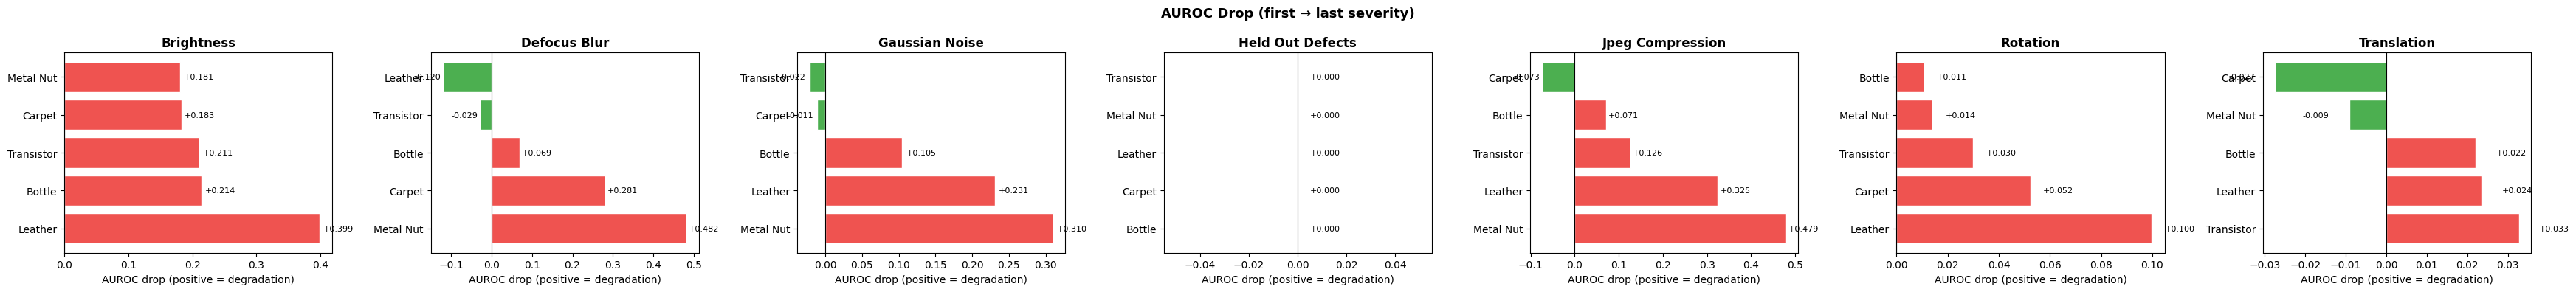

In [38]:
# For each (category, corruption) pair compute drop from lowest to highest severity
drop_records = []
for (cat, corr), grp in df.groupby(['category', 'corruption']):
    grp = grp.sort_values('severity')
    drop = grp.iloc[0]['auroc'] - grp.iloc[-1]['auroc']
    drop_records.append(dict(category=cat, corruption=corr,
                             auroc_start=grp.iloc[0]['auroc'],
                             auroc_end=grp.iloc[-1]['auroc'],
                             drop=drop))
drop_df = pd.DataFrame(drop_records)

n_corr = len(CORRUPTIONS)
fig, axes = plt.subplots(1, n_corr, figsize=(5 * n_corr, 4), sharey=False)
if n_corr == 1:
    axes = [axes]

fig.suptitle('AUROC Drop (first → last severity)', fontsize=13, fontweight='bold')

for ax, corr in zip(axes, CORRUPTIONS):
    sub = drop_df[drop_df['corruption'] == corr].sort_values('drop', ascending=False)
    colors = ['#EF5350' if d > 0 else '#4CAF50' for d in sub['drop']]
    bars = ax.barh([c.replace('_', ' ').title() for c in sub['category']],
                   sub['drop'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(corr.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('AUROC drop (positive = degradation)')
    for bar, (_, row) in zip(bars, sub.iterrows()):
        x = bar.get_width()
        ax.text(x + 0.005 if x >= 0 else x - 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{x:+.3f}', va='center', fontsize=8,
                ha='left' if x >= 0 else 'right')

plt.tight_layout()
plt.show()

In [39]:
# --- Extended analysis: robustness scores and slopes ---
robust_rows = []
for (cat, corr), grp in df.groupby(["category", "corruption"]):
    grp = grp.sort_values("severity")
    x = grp["severity"].to_numpy()
    y = grp["auroc"].to_numpy()
    if len(x) >= 2:
        slope = np.polyfit(x, y, 1)[0]
    else:
        slope = np.nan
    robust_rows.append({
        "category": cat,
        "corruption": corr,
        "n_points": len(grp),
        "mean_auroc": float(np.mean(y)),
        "min_auroc": float(np.min(y)),
        "degradation_slope": float(slope),
        "drop_first_last": float(y[0] - y[-1]) if len(y) >= 2 else np.nan,
    })

robust_df = pd.DataFrame(robust_rows)
display(robust_df.sort_values(["mean_auroc", "degradation_slope"]))


,category,corruption,n_points,mean_auroc,min_auroc,degradation_slope,drop_first_last
8,carpet,defocus_blur,6,0.432951,0.238544,-0.067405,0.280997
9,carpet,gaussian_noise,6,0.523697,0.454852,-0.003331,-0.010782
12,carpet,rotation,2,0.537820,0.511624,-0.052392,0.052392
7,carpet,brightness,6,0.561208,0.381402,-0.030169,0.182615
10,carpet,held_out_defects,1,0.567722,0.567722,NaN,NaN
13,carpet,translation,2,0.577746,0.564016,0.027460,-0.027460
11,carpet,jpeg_compression,6,0.633311,0.529650,0.013535,-0.073450
28,transistor,brightness,6,0.670833,0.536667,-0.045381,0.210833
18,leather,jpeg_compression,6,0.676215,0.505208,-0.076306,0.324653
14,leather,brightness,6,0.692323,0.431134,-0.076323,0.398727


,category,corruption,mean_auroc,rank_within_corruption
0,bottle,brightness,0.913095,1.0
21,metal_nut,brightness,0.912220,2.0
14,leather,brightness,0.692323,3.0
28,transistor,brightness,0.670833,4.0
7,carpet,brightness,0.561208,5.0
1,bottle,defocus_blur,0.953571,1.0
15,leather,defocus_blur,0.872396,2.0
29,transistor,defocus_blur,0.767500,3.0
22,metal_nut,defocus_blur,0.750659,4.0
8,carpet,defocus_blur,0.432951,5.0


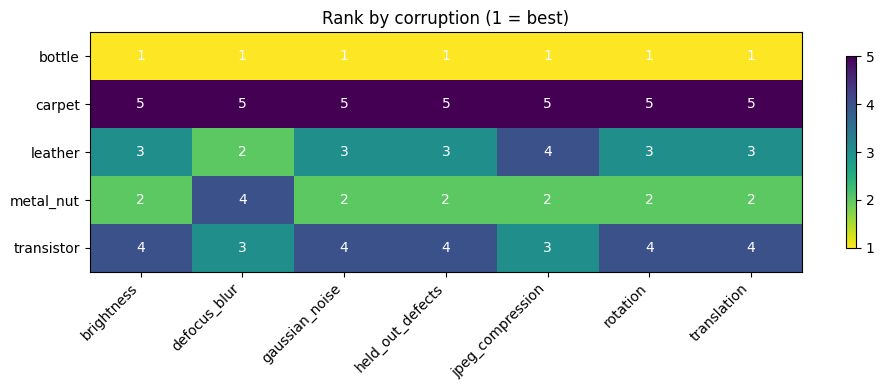

In [40]:
# --- Extended analysis: category rank per corruption ---
rank_df = (
    robust_df.groupby(["category", "corruption"])['mean_auroc']
    .mean()
    .reset_index()
)
rank_df['rank_within_corruption'] = rank_df.groupby('corruption')['mean_auroc'].rank(ascending=False, method='min')
display(rank_df.sort_values(['corruption', 'rank_within_corruption']))

pivot_rank = rank_df.pivot_table(index='category', columns='corruption', values='rank_within_corruption')
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_rank.values, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(pivot_rank.columns)))
ax.set_xticklabels(pivot_rank.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_rank.index)))
ax.set_yticklabels(pivot_rank.index)
ax.set_title('Rank by corruption (1 = best)')
for i in range(pivot_rank.shape[0]):
    for j in range(pivot_rank.shape[1]):
        v = pivot_rank.values[i, j]
        ax.text(j, i, f"{v:.0f}" if not np.isnan(v) else '—', ha='center', va='center', color='white')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()


In [41]:
# --- Extended analysis: anomaly/outlier runs ---
z = df.copy()
z['zscore'] = z.groupby('corruption')['auroc'].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0))
outliers = z[np.abs(z['zscore']) >= 1.5].sort_values('zscore')
print('Potential outlier (category, corruption, severity) points:')
display(outliers[['category','corruption','severity','auroc','zscore']].head(50))


Potential outlier (category, corruption, severity) points:


,category,corruption,severity,auroc,zscore
39,carpet,defocus_blur,4,0.238544,-2.525980
40,carpet,defocus_blur,5,0.283019,-2.308631
34,carpet,brightness,5,0.381402,-2.140658
45,carpet,gaussian_noise,4,0.454852,-2.006780
63,leather,brightness,5,0.431134,-1.851783
43,carpet,gaussian_noise,2,0.485175,-1.807096
55,carpet,rotation,1,0.511624,-1.734072
111,metal_nut,jpeg_compression,5,0.487154,-1.721950
56,carpet,translation,0,0.564016,-1.652443
47,carpet,held_out_defects,0,0.567722,-1.629492
